In [7]:
import kagglehub
import warnings

warnings.filterwarnings("ignore")
# Download latest version
path = kagglehub.dataset_download("chirag19/air-passengers", output_dir="air_dataset")

print("Path to dataset files:", path)

Path to dataset files: air_dataset


In [9]:
data_path = "air_dataset/AirPassengers.csv"

In [10]:
import pandas as pd
data = pd.read_csv(data_path)
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        144 non-null    str  
 1   #Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


## Data Preparation

In [12]:
data.columns = ['month', 'passengers']
data['month'] = pd.to_datetime(data['month'])
data = data.set_index('month')
data.head()

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


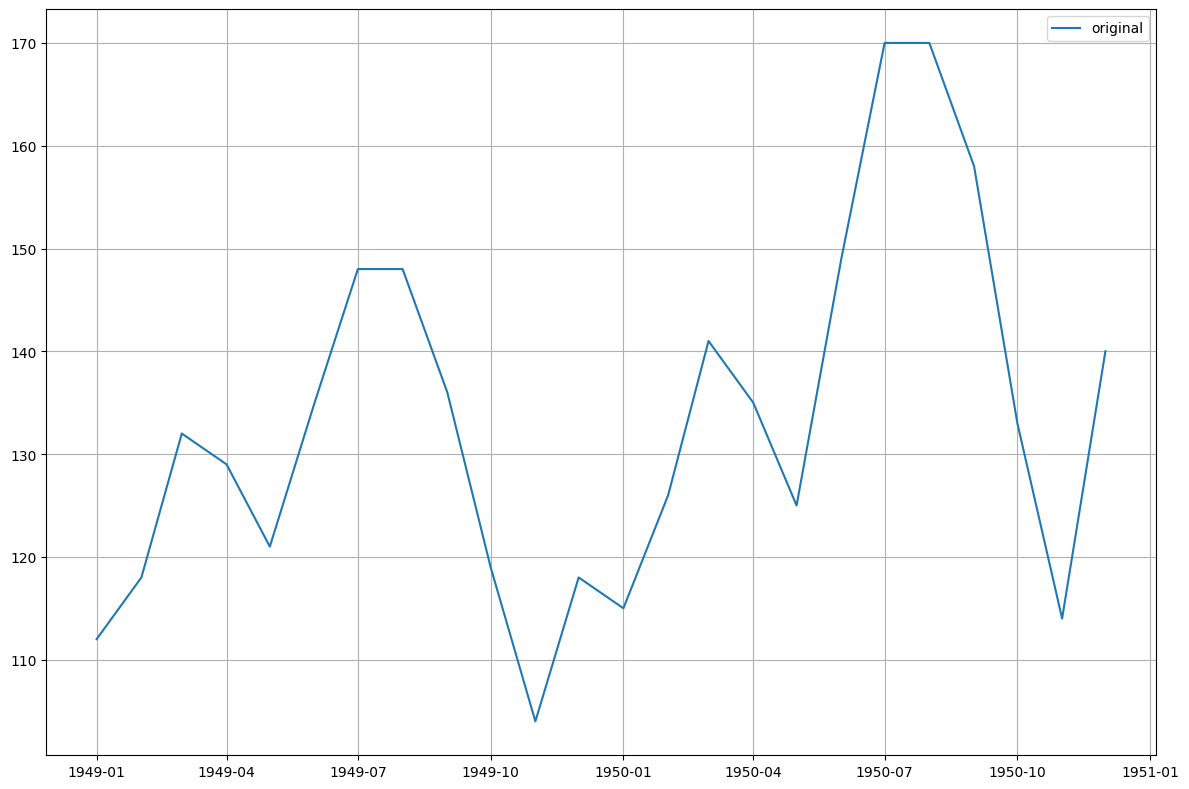

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(data.index[:24], data['passengers'].iloc[:24], label='original')
ax.legend()
ax.grid()
fig.tight_layout()

<Axes: xlabel='month'>

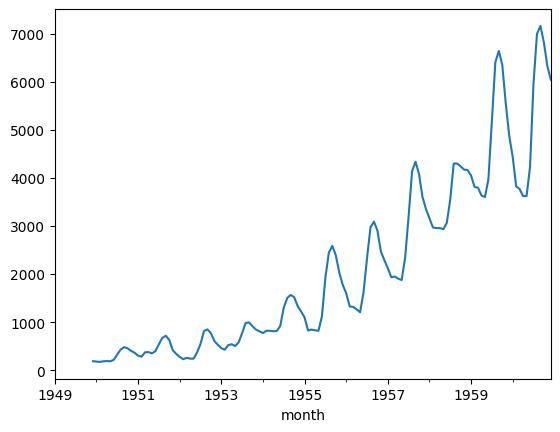

In [18]:
data['passengers'].rolling(12).var().plot()

## Create Time Features

1. Metadata Time Features
   - dayofweek
   - dayofyear
   - month
   - year
   - quarter

In [23]:
time_series = data.copy()
time_series['dayofweek'] = time_series.index.dayofweek
time_series['dayofyear'] = time_series.index.dayofyear
time_series['month']  = time_series.index.month
time_series['year'] = time_series.index.year
time_series['quarter'] = time_series.index.quarter
time_series.head()

,passengers,dayofweek,dayofyear,month,year,quarter
month,,,,,,
1949-01-01,112,5,1,1,1949,1
1949-02-01,118,1,32,2,1949,1
1949-03-01,132,1,60,3,1949,1
1949-04-01,129,4,91,4,1949,2
1949-05-01,121,6,121,5,1949,2


In [35]:
from sklearn.tree import DecisionTreeRegressor
dt_dp2_model = DecisionTreeRegressor(max_depth=10)

In [36]:
X = time_series.drop(columns=['passengers'])
y = time_series['passengers']

In [37]:
dt_dp2_model.fit(X, y)
y_predictions = dt_dp2_model.predict(X)

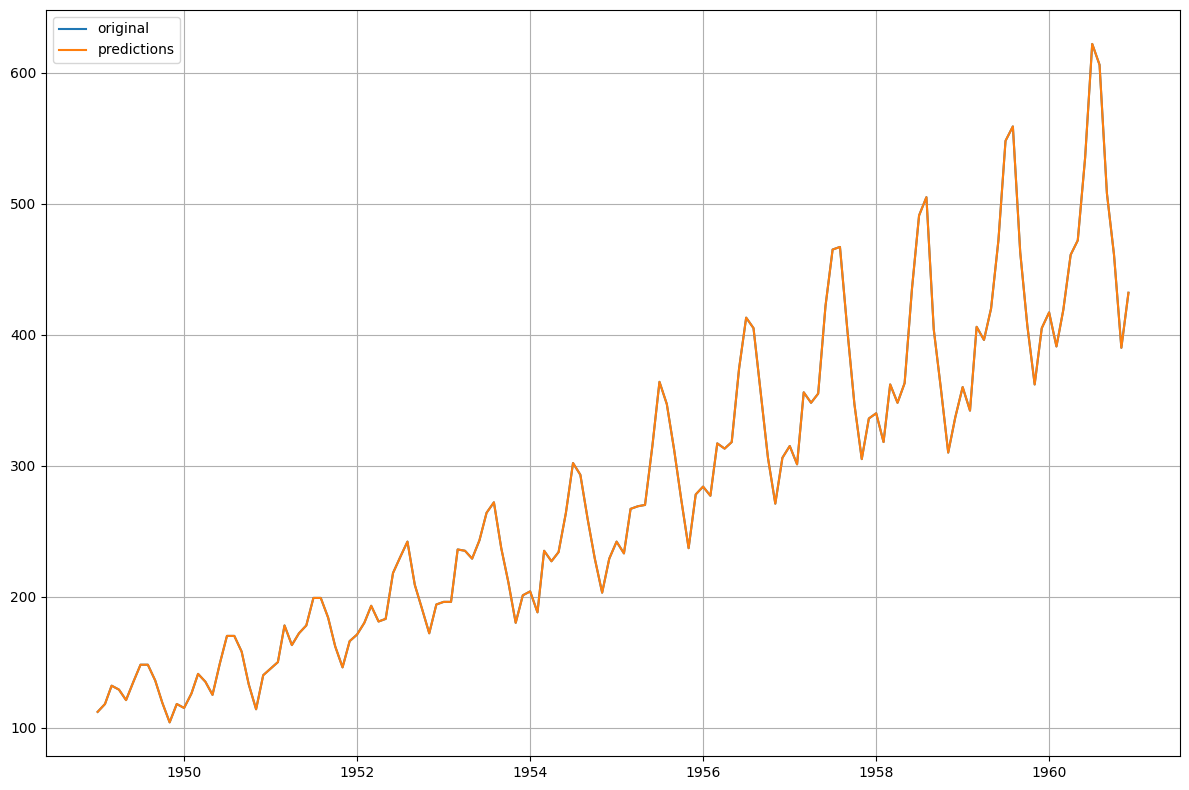

In [38]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='original')
ax.plot(X.index, y_predictions, label='predictions')
ax.legend(loc='upper left')
ax.grid()
fig.tight_layout()

In [39]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y, y_predictions)

0.0

In [47]:
split=24
X_train, X_test, y_train, y_test = X[:-split], X[-split:], y[:-split], y[-split:]
dt_dp2_model.fit(X_train, y_train)
y_predictions = dt_dp2_model.predict(X_test)
y_train_predictions = dt_dp2_model.predict(X_train)

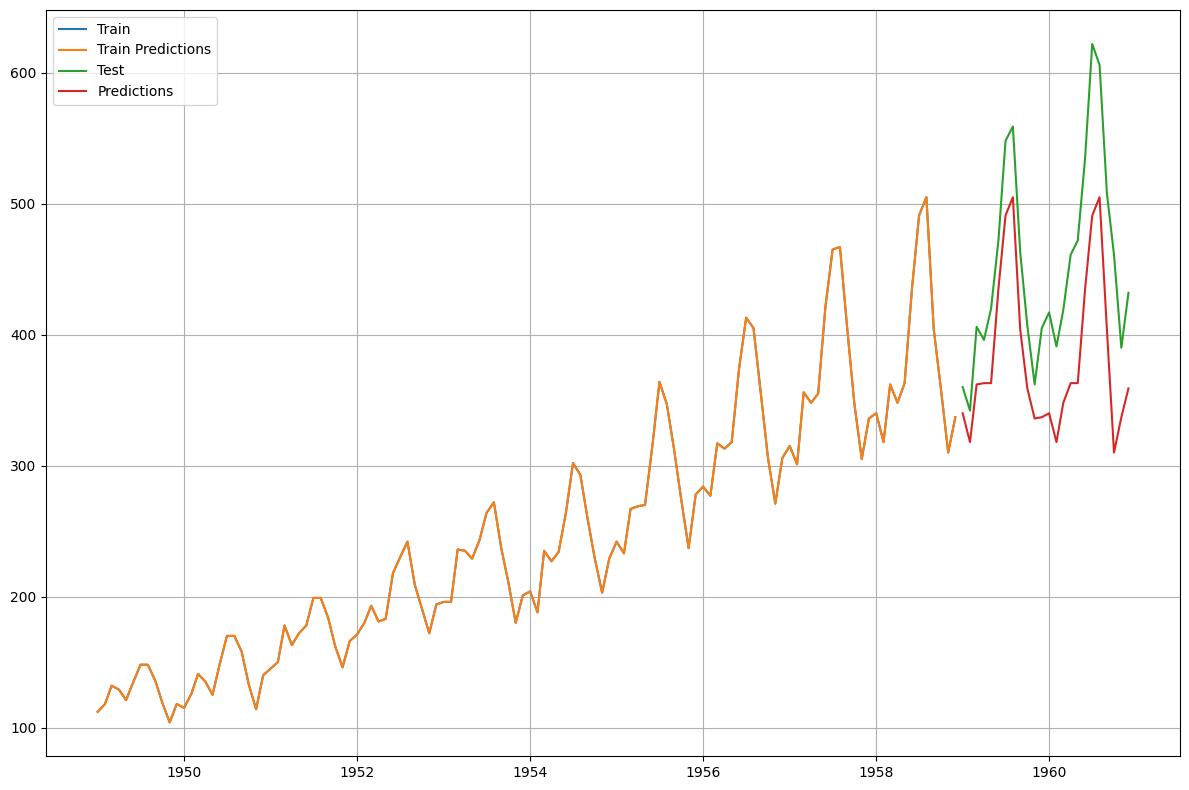

In [49]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X_train.index, y_train, label='Train')
ax.plot(X_train.index, y_train_predictions, label='Train Predictions')
ax.plot(X_test.index, y_test, label='Test')
ax.plot(X_test.index, y_predictions, label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

In [50]:
mean_absolute_percentage_error(y_train, y_train_predictions)

0.0

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

In [72]:
rf_model_w_bootstrap = RandomForestRegressor(bootstrap=True)
rf_model_wo_bootstrap = RandomForestRegressor(bootstrap=False)

cv_strategy  = KFold(n_splits=3, shuffle=False)

scores = {}
scores['bootstrap'] = - cross_val_score(rf_model_w_bootstrap, X, y, cv=cv_strategy, scoring='neg_mean_squared_error')
scores['wo_bootstrap'] = - cross_val_score(rf_model_wo_bootstrap, X, y, cv=cv_strategy, scoring='neg_mean_squared_error')

In [73]:
import numpy as np

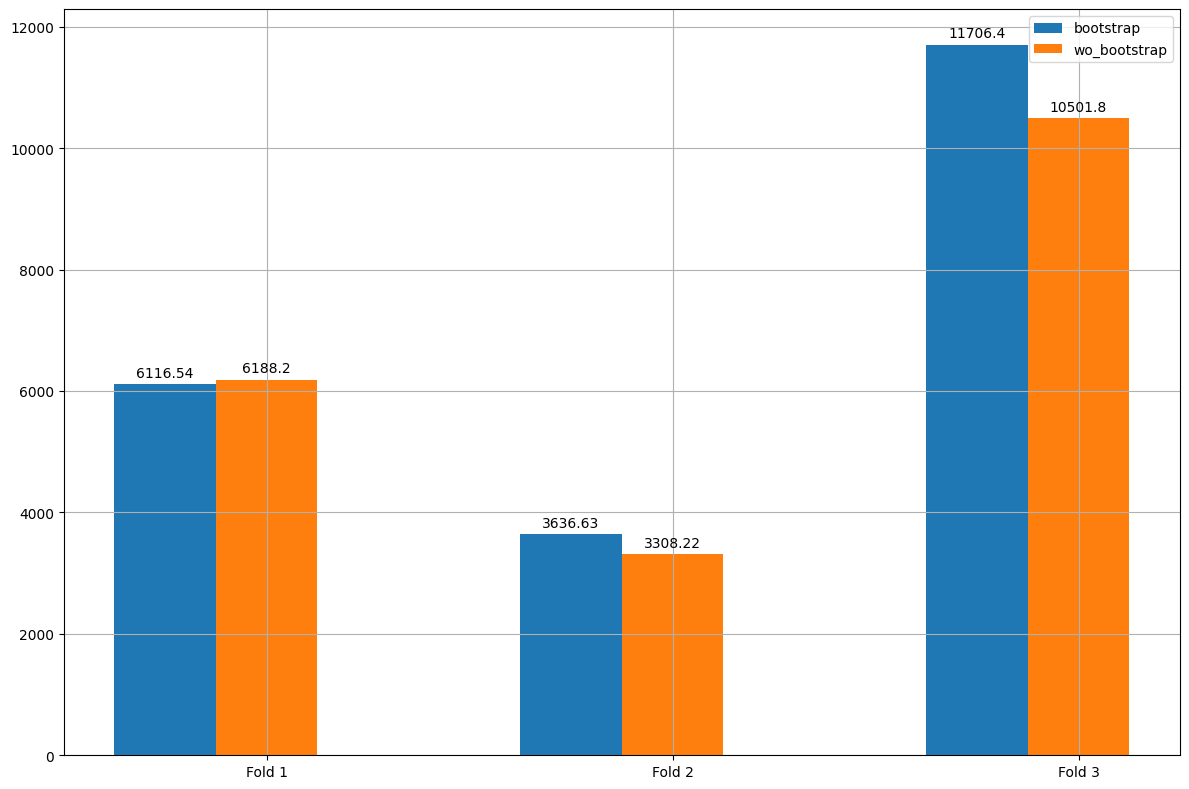

In [74]:
fig, ax = plt.subplots(figsize=(12, 8))
w = 0.25
multiplier = 0
x = np.arange(3)
for model, values in scores.items():
    offset  = w * multiplier
    rects = ax.bar(x+offset, values, w,label=model)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_xticks(x + w, [f"Fold {i}" for i in range(1, 4)])
ax.legend()
ax.grid()
fig.tight_layout()

In [82]:
time_series['dayofweek_sinsuidal'] = np.sin(2*np.pi*time_series['dayofweek']/7)
time_series['month_sinsuidal'] = np.sin(2*np.pi*time_series['month']/12)

In [86]:
X = time_series.drop(columns=['passengers'])
y = time_series['passengers']

In [90]:
rf_model_wo_bootstrap = RandomForestRegressor(bootstrap=False)
rf_model_wo_bootstrap.fit(X, y)
y_predictions = rf_model_wo_bootstrap.predict(X)

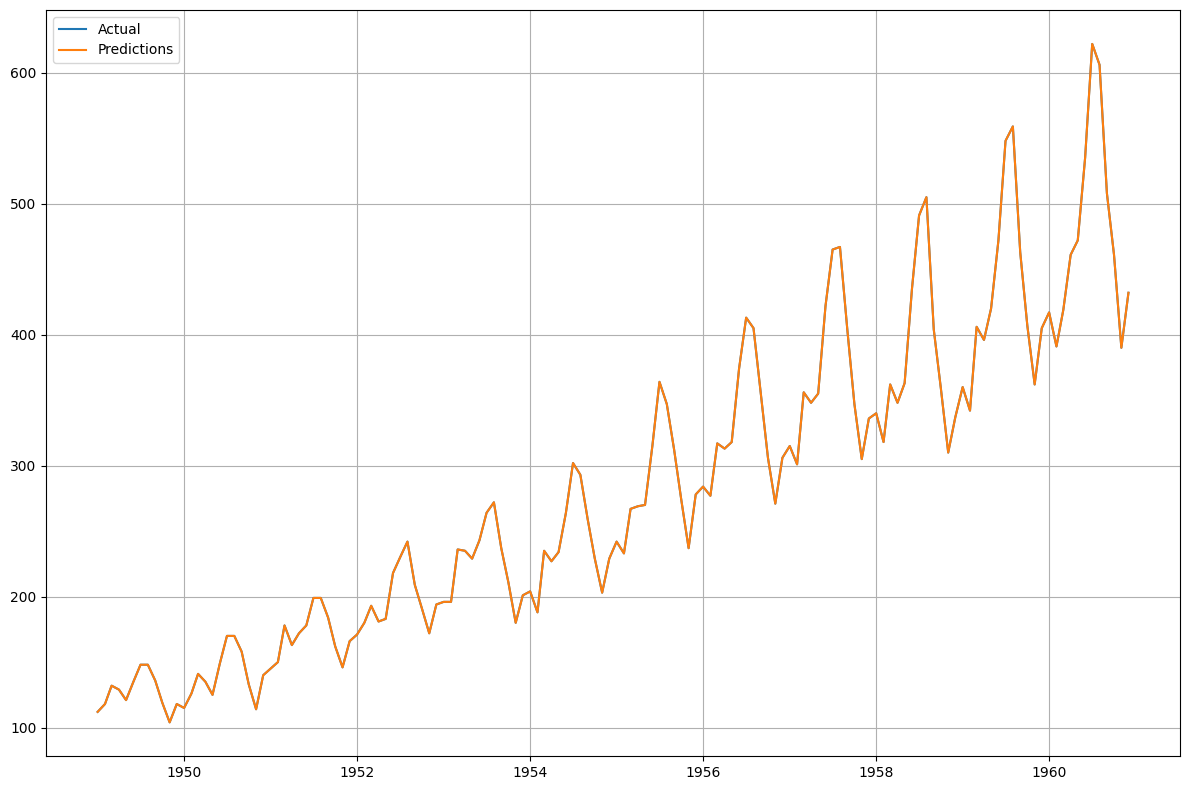

In [91]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='Actual')
ax.plot(X.index, y_predictions, label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

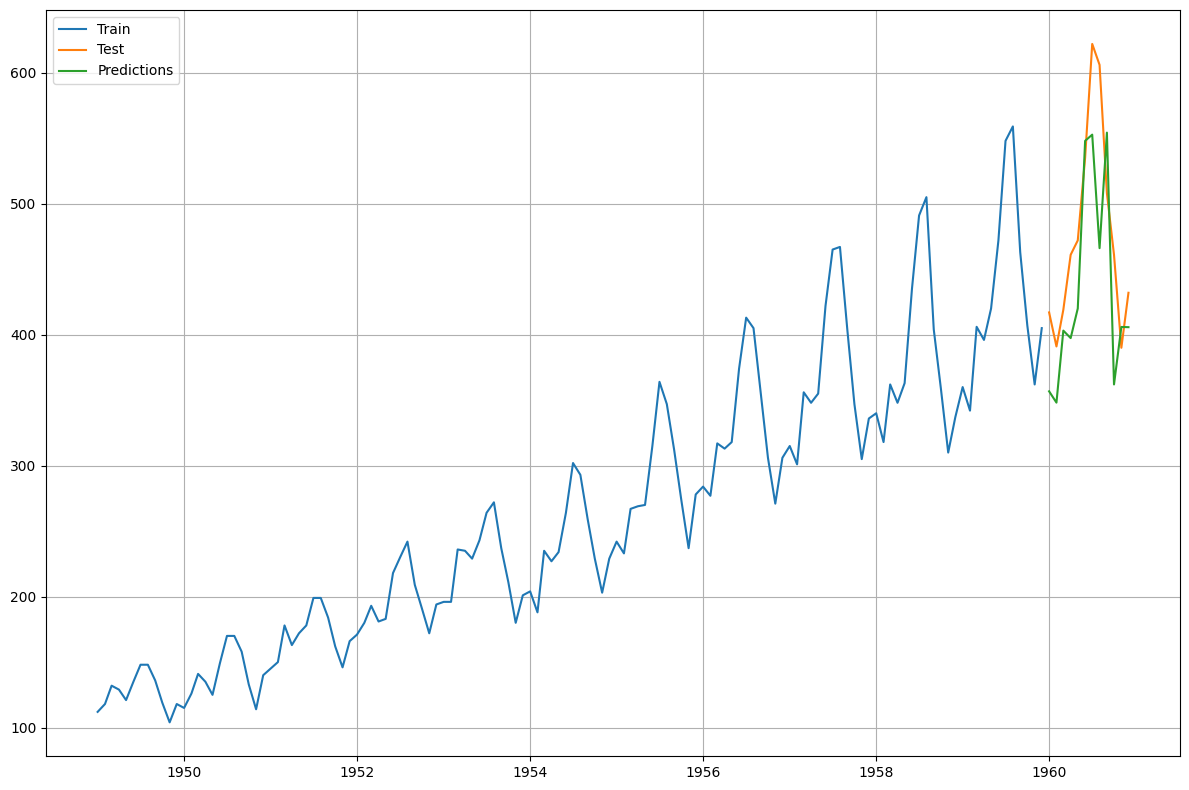

In [93]:
split = 12
X_train, X_test, y_train, y_test = X[:-split], X[-split:], y[:-split], y[-split:]
rf_model_wo_bootstrap.fit(X_train, y_train)
y_predictions = rf_model_wo_bootstrap.predict(X_test)
fig, ax  = plt.subplots(figsize=(12, 8))
ax.plot(X_train.index, y_train, label='Train')
ax.plot(X_test.index, y_test, label='Test')
ax.plot(X_test.index, y_predictions, label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

In [134]:
X_train

,dayofweek,dayofyear,month,year,quarter,dayofweek_sinsuidal,month_sinsuidal
month,,,,,,,
1949-01-01,5,1,1,1949,1,-0.974928,5.000000e-01
1949-02-01,1,32,2,1949,1,0.781831,8.660254e-01
1949-03-01,1,60,3,1949,1,0.781831,1.000000e+00
1949-04-01,4,91,4,1949,2,-0.433884,8.660254e-01
1949-05-01,6,121,5,1949,2,-0.781831,5.000000e-01
...,...,...,...,...,...,...,...
1959-08-01,5,213,8,1959,3,-0.974928,-8.660254e-01
1959-09-01,1,244,9,1959,3,0.781831,-1.000000e+00
1959-10-01,3,274,10,1959,4,0.433884,-8.660254e-01


In [135]:
dt_dp2_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

## Forecasting

In [119]:
def make_future_dataframe(horizon: int, last_date: pd.Timestamp) -> pd.DataFrame:
    forecast_dates = [last_date + pd.DateOffset(months=i) for i in range(1, horizon + 1)]
    future_df = pd.DataFrame(index=forecast_dates)
    future_df['dayofweek'] = future_df.index.dayofweek
    future_df['dayofyear'] = future_df.index.dayofyear
    future_df['month'] = future_df.index.month
    future_df['year'] = future_df.index.year
    future_df['quarter'] = future_df.index.quarter
    future_df['dayofweek_sinsuidal'] = np.sin(2*np.pi*future_df['dayofweek']/7)
    future_df['month_sinsuidal'] = np.sin(2*np.pi*future_df['month']/12)
    return future_df

In [131]:
future_df = make_future_dataframe(48, time_sereis.index[-1])
future_df

,dayofweek,dayofyear,month,year,quarter,dayofweek_sinsuidal,month_sinsuidal
1961-01-01,6,1,1,1961,1,-0.781831,5.000000e-01
1961-02-01,2,32,2,1961,1,0.974928,8.660254e-01
1961-03-01,2,60,3,1961,1,0.974928,1.000000e+00
1961-04-01,5,91,4,1961,2,-0.974928,8.660254e-01
1961-05-01,0,121,5,1961,2,0.000000,5.000000e-01
1961-06-01,3,152,6,1961,2,0.433884,1.224647e-16
1961-07-01,5,182,7,1961,3,-0.974928,-5.000000e-01
1961-08-01,1,213,8,1961,3,0.781831,-8.660254e-01
1961-09-01,4,244,9,1961,3,-0.433884,-1.000000e+00
1961-10-01,6,274,10,1961,4,-0.781831,-8.660254e-01


In [132]:
forecast_dt = dt_dp2_model.predict(future_df)
forecast_rf = rf_model_wo_bootstrap.predict(future_df)

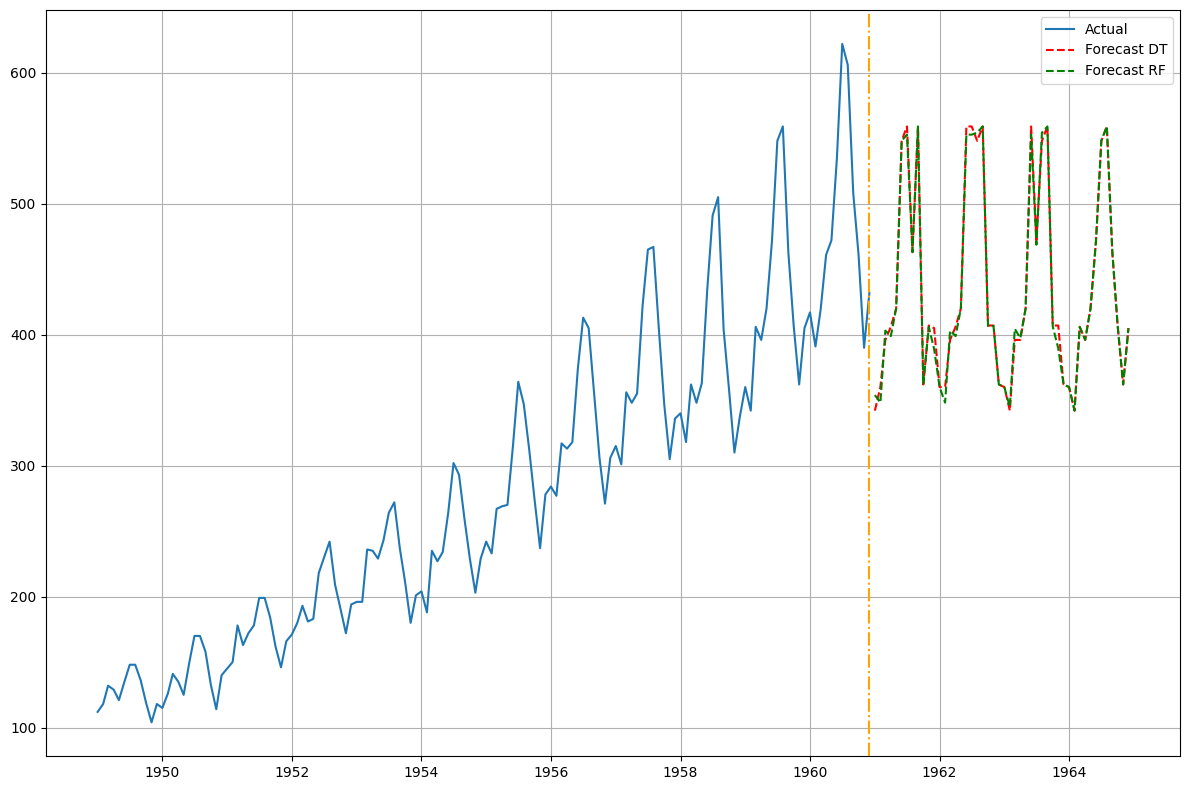

In [133]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='Actual')
ax.plot(future_df.index, forecast_dt,color='red',linestyle='--',  label='Forecast DT')
ax.plot(future_df.index, forecast_rf,color='green',linestyle='--',  label='Forecast RF')
ax.axvline(X.index[-1], linestyle='-.', color='orange')
ax.legend()
ax.grid()
fig.tight_layout()

## Create Time Features
    - Lag Features

In [280]:
def create_lag_features(num_lags: int, data: pd.DataFrame, col_name: str)-> pd.DataFrame:
    df_ = data.copy()
    for i in range(1, num_lags+1):
        df_[f'lag{i}'] = df_[col_name].shift(i)
    return df_.dropna()

In [281]:
time_series = data.copy()
time_series = create_lag_features(12, time_series, 'passengers')
time_series

,passengers,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12
month,,,,,,,,,,,,,
1950-01-01,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
1950-02-01,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
1950-03-01,141,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
1950-04-01,135,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
1950-05-01,125,135.0,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960-08-01,606,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0,463.0,559.0
1960-09-01,508,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0,463.0
1960-10-01,461,508.0,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0


In [282]:
from sklearn.linear_model import LinearRegression

In [283]:
dt_model = DecisionTreeRegressor(max_depth=10)
reg_model = LinearRegression()
X, y = time_series.drop(columns=['passengers']), time_series['passengers']
dt_model.fit(X, y)
y_predictions = dt_model.predict(X)

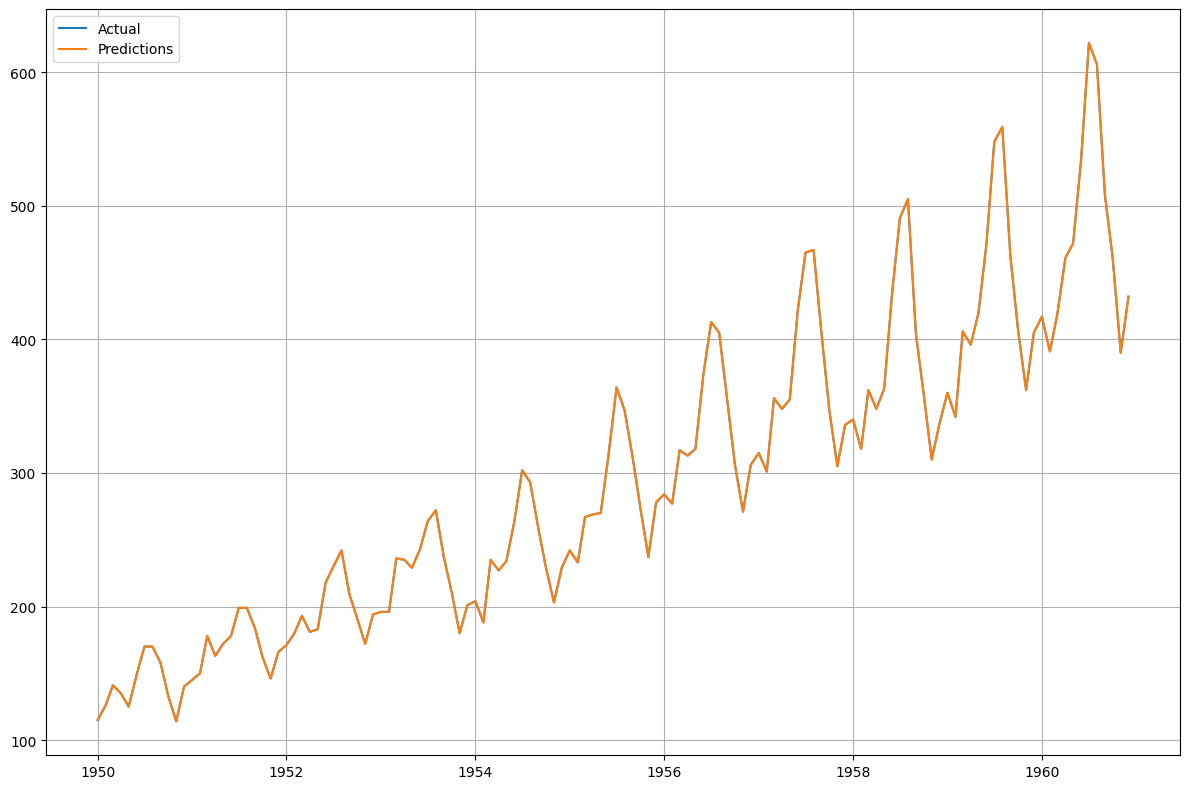

In [284]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='Actual')
ax.plot(X.index, y_predictions, label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

In [285]:
split = 36
X_train, X_test, y_train, y_test = X[:-split], X[-split:], y[:-split], y[-split:]
dt_model.fit(X_train, y_train)
y_predictions = dt_model.predict(X_test)


In [286]:
mean_absolute_percentage_error(y_test, y_predictions)

0.0884512394432477

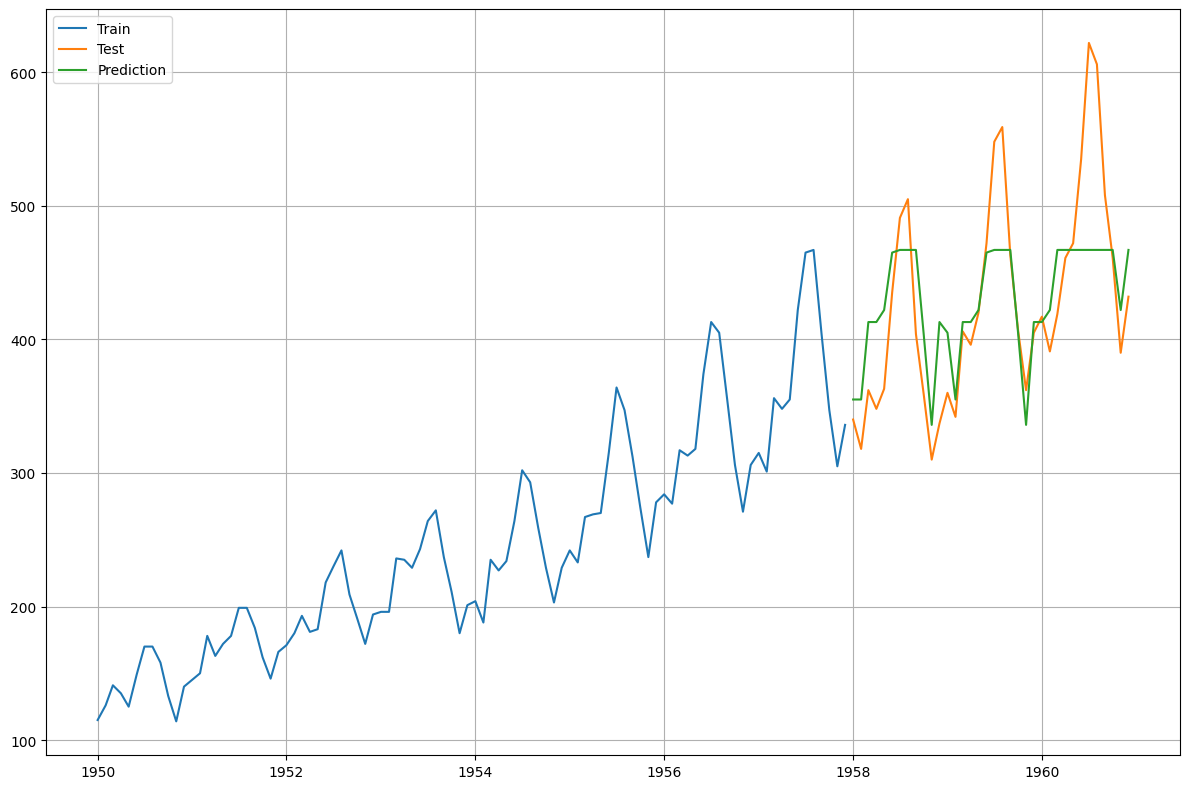

In [287]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(X_train.index, y_train, label='Train')
ax.plot(X_test.index, y_test, label='Test')
ax.plot(X_test.index, y_predictions, label='Prediction')
ax.legend()
ax.grid()
fig.tight_layout()

In [288]:
X

,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12
month,,,,,,,,,,,,
1950-01-01,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
1950-02-01,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
1950-03-01,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
1950-04-01,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
1950-05-01,135.0,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1960-08-01,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0,463.0,559.0
1960-09-01,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0,463.0
1960-10-01,508.0,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0


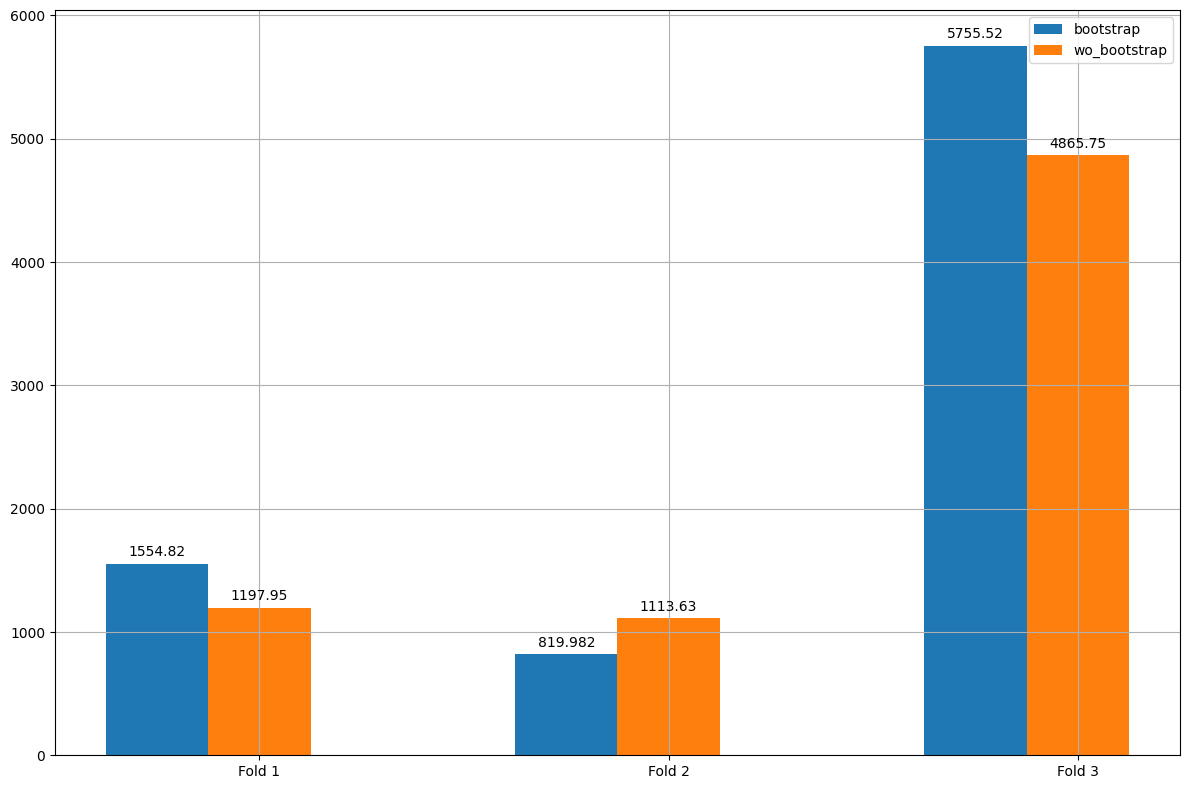

In [289]:
rf_model_w_bootstrap = RandomForestRegressor(bootstrap=True)
rf_model_wo_bootstrap = RandomForestRegressor(bootstrap=False)

cv_strategy  = KFold(n_splits=3, shuffle=False)

scores = {}
scores['bootstrap'] = - cross_val_score(rf_model_w_bootstrap, X, y, cv=cv_strategy, scoring='neg_mean_squared_error')
scores['wo_bootstrap'] = - cross_val_score(rf_model_wo_bootstrap, X, y, cv=cv_strategy, scoring='neg_mean_squared_error')

fig, ax = plt.subplots(figsize=(12, 8))
w = 0.25
multiplier = 0
x = np.arange(3)
for model, values in scores.items():
    offset  = w * multiplier
    rects = ax.bar(x+offset, values, w,label=model)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_xticks(x + w, [f"Fold {i}" for i in range(1, 4)])
ax.legend()
ax.grid()
fig.tight_layout()

In [290]:
rf_model_wo_bootstrap = RandomForestRegressor(bootstrap=False)
rf_model_wo_bootstrap.fit(X, y)
y_predictions = rf_model_wo_bootstrap.predict(X)

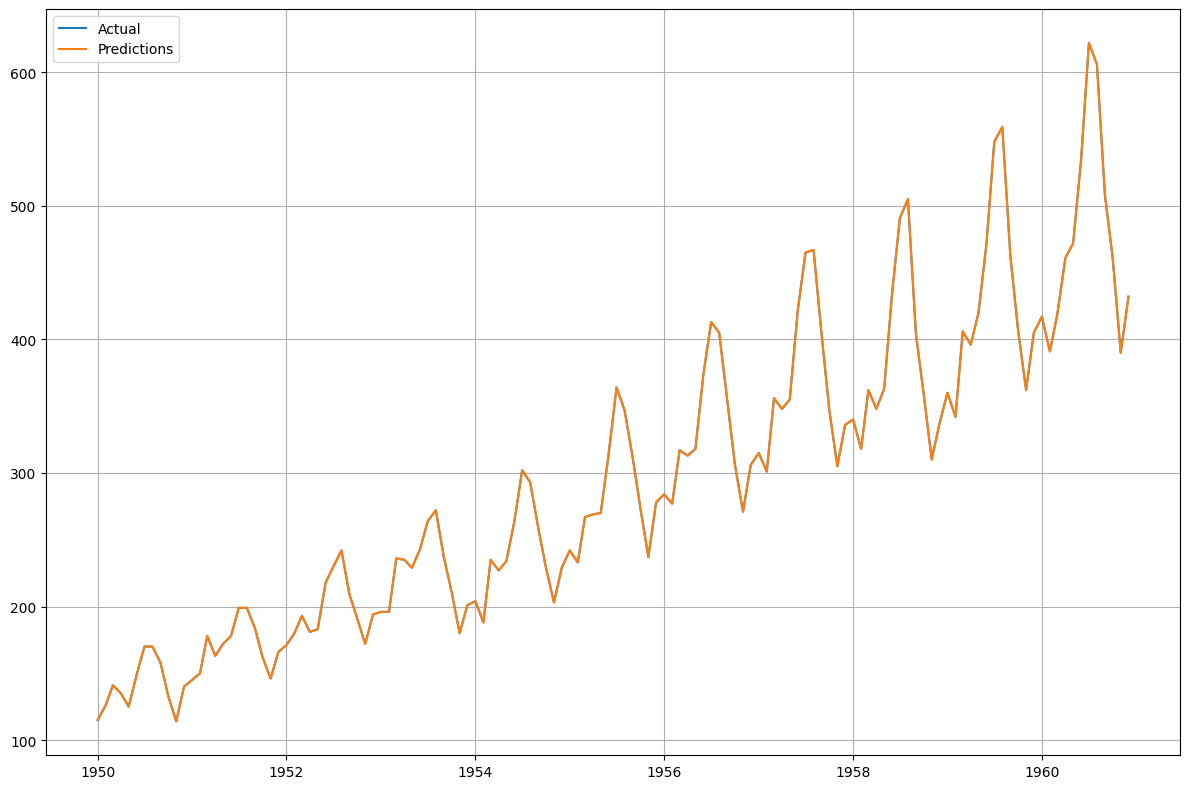

In [291]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y,label='Actual')
ax.plot(X.index, y_predictions, label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

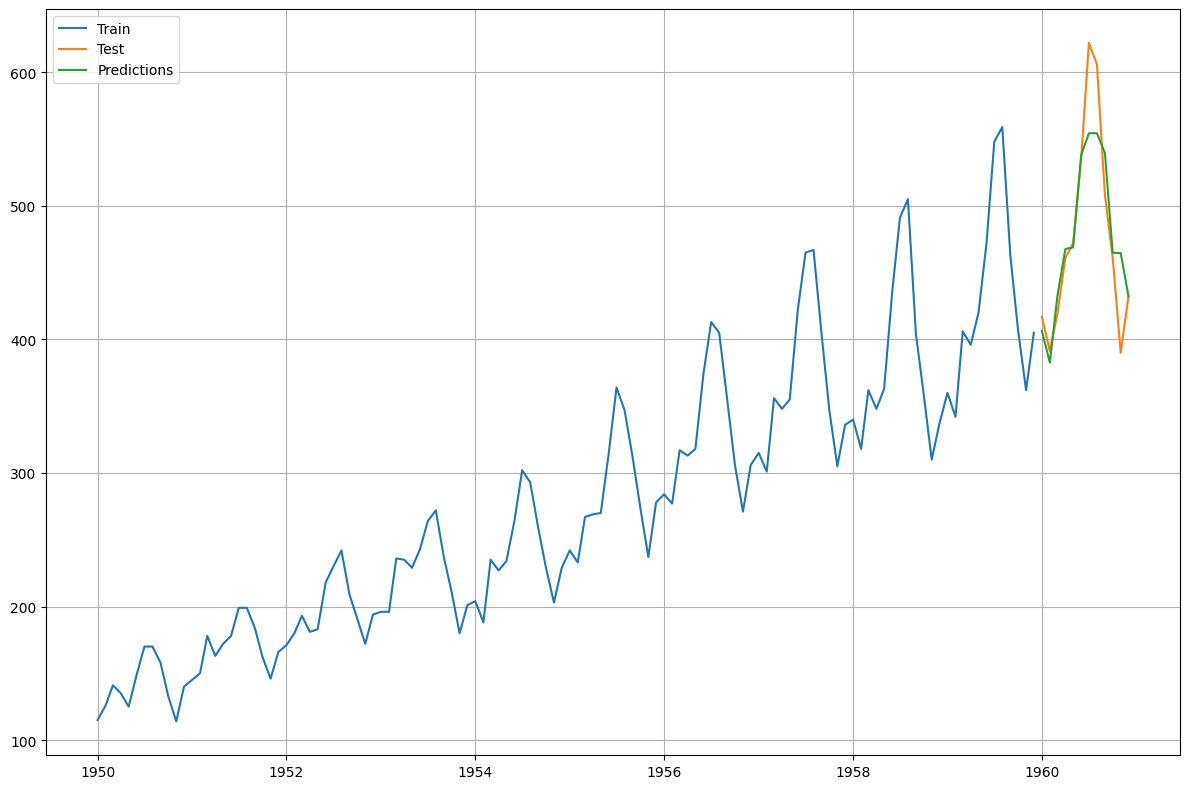

In [292]:
split = 12
X_train, X_test, y_train, y_test = X[:-split], X[-split:], y[:-split], y[-split:]
rf_model_wo_bootstrap.fit(X_train, y_train)
y_predictions = rf_model_wo_bootstrap.predict(X_test)

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X_train.index, y_train,label='Train')
ax.plot(X_test.index, y_test,label='Test')
ax.plot(X_test.index, y_predictions,label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

In [293]:
X.iloc[-1].shift(1)

lag1       NaN
lag2     390.0
lag3     461.0
lag4     508.0
lag5     606.0
lag6     622.0
lag7     535.0
lag8     472.0
lag9     461.0
lag10    419.0
lag11    391.0
lag12    417.0
Name: 1960-12-01 00:00:00, dtype: float64

In [298]:
horizon = 72
input_ = X.iloc[-1]
forecasts = []
forecast_dates = [X.index[-1] + pd.DateOffset(months=i) for i in range(1, horizon +1)]
future_df = pd.DataFrame(index=forecast_dates, columns=['forecast'])
for _ in forecast_dates:
    forecast = rf_model_wo_bootstrap.predict([input_])
    input_ = input_.shift(1)
    input_.iloc[0] = forecast
    forecasts.append(forecast[0])
future_df['forecast'] = forecasts

In [299]:
future_df

,forecast
1961-01-01,432.31
1961-02-01,465.17
1961-03-01,466.82
1961-04-01,468.77
1961-05-01,537.15
...,...
1966-08-01,554.38
1966-09-01,554.38
1966-10-01,554.38
1966-11-01,554.38


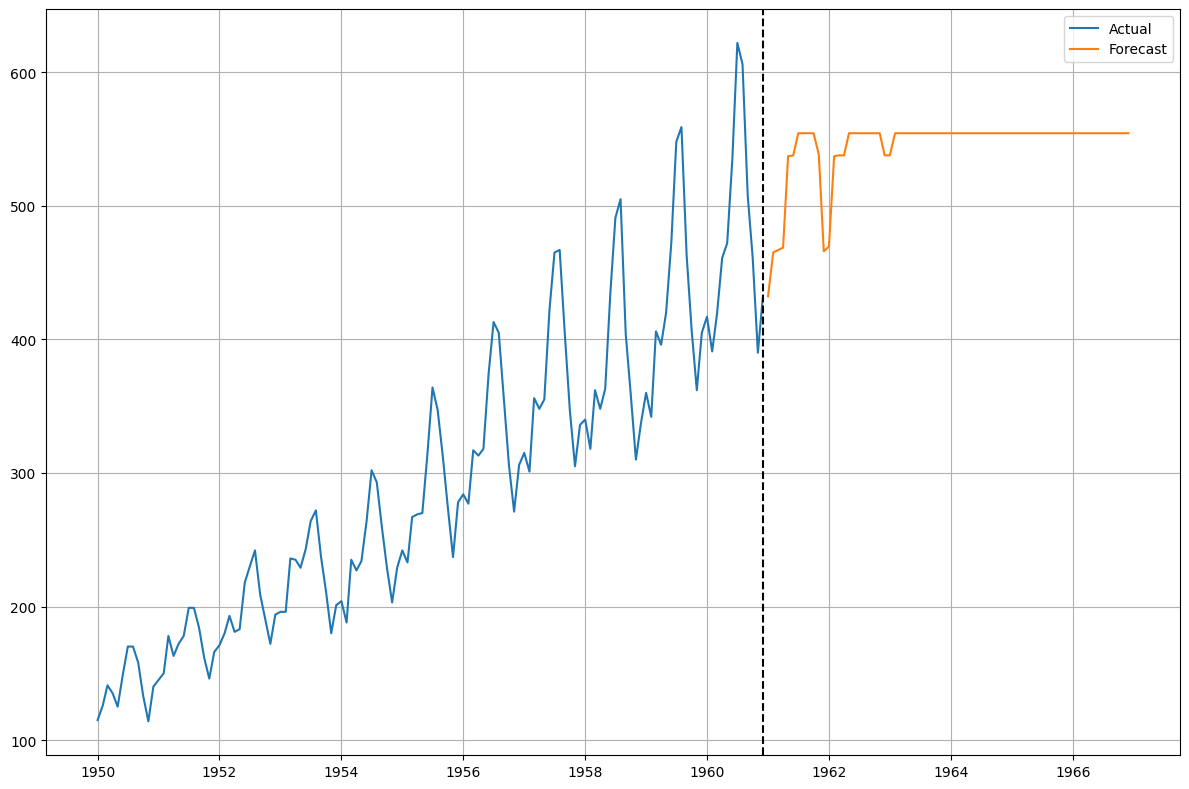

In [300]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='Actual')
ax.plot(future_df.index, future_df['forecast'], label='Forecast')
ax.axvline(X.index[-1], linestyle='--', color='black')
ax.legend()
ax.grid()
fig.tight_layout()

## Extrapolitation Problem

In [308]:
time_series = data.copy()
time_series = create_lag_features(12, time_series, 'passengers')
time_series

,passengers,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12
month,,,,,,,,,,,,,
1950-01-01,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
1950-02-01,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
1950-03-01,141,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
1950-04-01,135,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
1950-05-01,125,135.0,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960-08-01,606,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0,463.0,559.0
1960-09-01,508,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0,463.0
1960-10-01,461,508.0,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0,407.0


In [309]:
X = time_series.drop(columns=['passengers'])
y = time_series['passengers']

In [327]:
from sklearn.linear_model import ElasticNetCV
trend_model = ElasticNetCV(cv=5)
trend_model.fit(X, y)

,"l1_ratio l1_ratio: float or list of float, default=0.5Float between 0 and 1 passed to ElasticNet (scaling betweenl1 and l2 penalties). For ``l1_ratio = 0``the penalty is an L2 penalty. For ``l1_ratio = 1`` it is an L1 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1 and L2This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.",0.5
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path, used for each l1_ratio... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0


In [328]:
trend_prediction = trend_model.predict(X)

In [329]:
y_detrend = y - trend_prediction

In [330]:
rf_model = RandomForestRegressor(bootstrap=False)
rf_model.fit(X, y_detrend)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

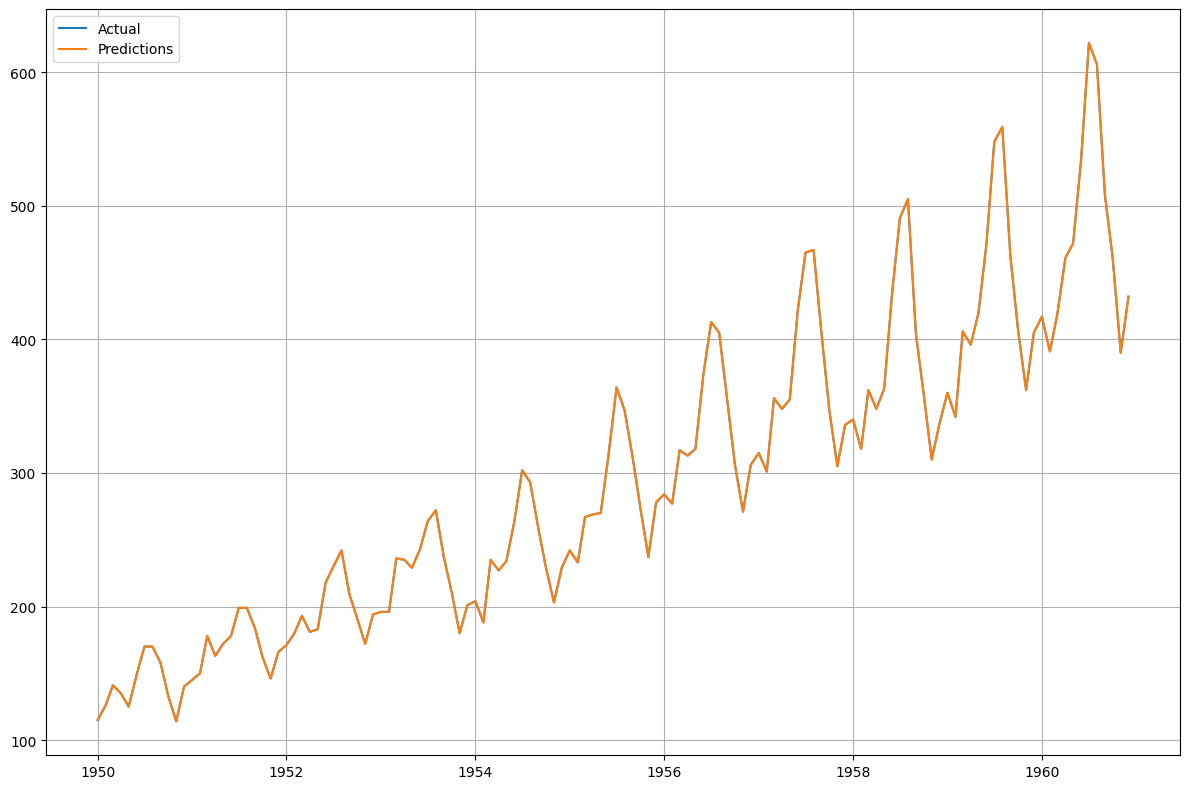

In [331]:
y_predictions = (rf_model.predict(X) + 
                 trend_model.predict(X)
                )
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='Actual')
ax.plot(X.index, y_predictions, label='Predictions')
ax.legend()
ax.grid()
fig.tight_layout()

In [332]:
horizon = 72
input_ = X.iloc[-1]
forecasts = []
forecast_dates = [X.index[-1] + pd.DateOffset(months=i) for i in range(1, horizon +1)]
future_df = pd.DataFrame(index=forecast_dates, columns=['forecast'])
for _ in forecast_dates:
    forecast = rf_model.predict([input_]) + trend_model.predict([input_]) 
    input_ = input_.shift(1)
    input_.iloc[0] = forecast
    forecasts.append(forecast[0])
future_df['forecast'] = forecasts

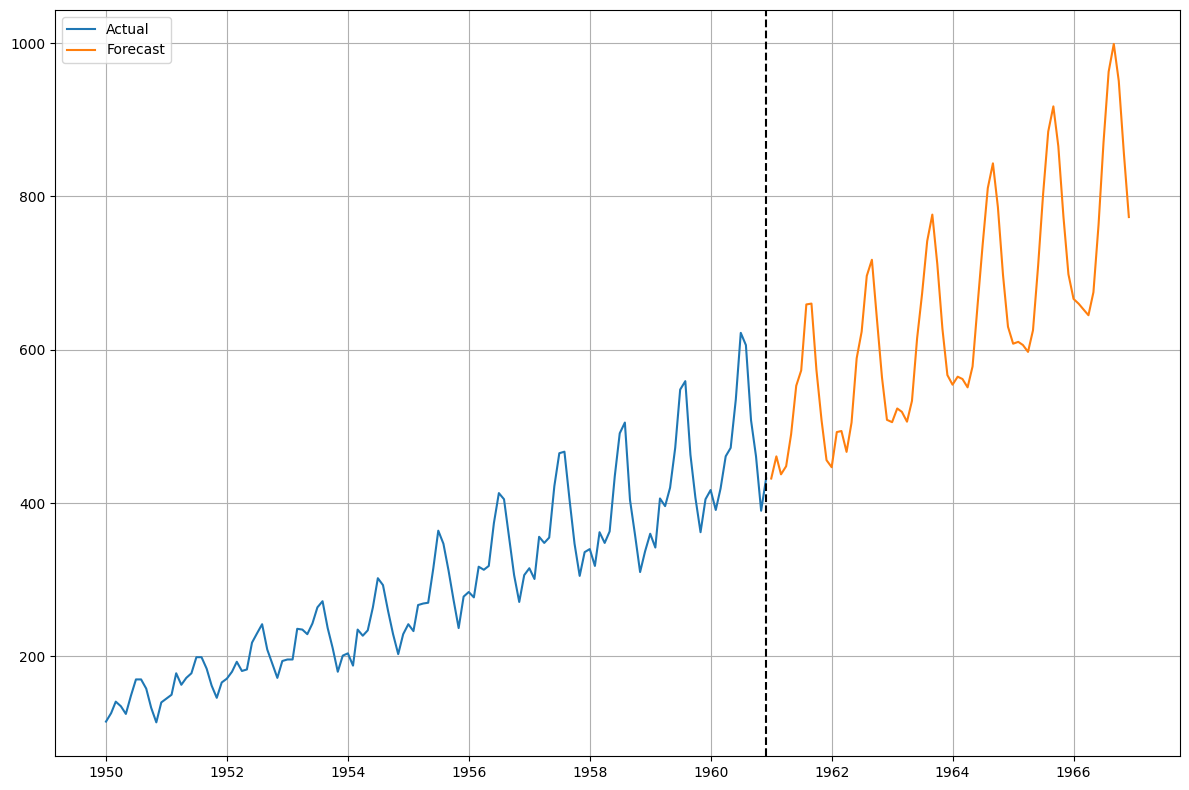

In [333]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(X.index, y, label='Actual')
ax.plot(future_df.index, future_df['forecast'], label='Forecast')
ax.axvline(X.index[-1], linestyle='--', color='black')
ax.legend()
ax.grid()
fig.tight_layout()